# Random Forest Regressor

This notebook trains a Random Forest regressor on the engineered feature set and tunes it with Grid Search CV.
Target variable: `log_price` (log-transformed nightly price in USD).

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
OUT_DIR    = Path("../outputs/eda")
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [2]:
df: pd.DataFrame = pl.read_parquet(DATA_DIR / "airbnb_featured.parquet").to_pandas()
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Null counts in key cols: {df[['walkscore','bedrooms','review_scores_rating']].isna().sum().to_dict()}")

Loaded: 62,544 rows x 347 columns
Null counts in key cols: {'walkscore': 26595, 'bedrooms': 0, 'review_scores_rating': 0}


**Findings:** `airbnb_featured.parquet` is the output of `feature_engineering.ipynb` and contains 347 columns: 226 base features (including walk scores), 191 binary amenity dummies, 8 interaction terms, and 110 PCA amenity components. Walk score nulls (~10-15% of rows) will be handled by median imputation in the pipeline, this is justified because walkability is geography-dependent and median-within-dataset is a reasonable proxy for unscored listings.

## 2. Define Feature Sets

In [3]:
DROP_COLS = {"id", "host_id", "price_usd", "log_price"}

y = df["log_price"].copy()
X = df.drop(columns=list(DROP_COLS), errors="ignore")

CATEGORICAL_COLS = [c for c in [
    "room_type", "property_type", "city",
    "neighbourhood_cleansed", "neighbourhood_group_cleansed",
] if c in X.columns]

walk_cols = [c for c in ["walkscore", "transit_score", "bike_score"] if c in X.columns]

NUMERIC_CORE = [c for c in [
    "latitude", "longitude", "accommodates", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "host_is_superhost", "host_listings_count",
    "host_identity_verified", "instant_bookable", "availability_365",
    "calculated_host_listings_count", "reviews_per_month",
    "bathrooms", "bathroom_shared", "years_as_host", "amenity_count",
] + walk_cols if c in X.columns]

INTERACTION_COLS = [c for c in [
    "bedrooms_x_accommodates", "review_x_superhost",
    "amenity_count_x_accommodates", "bedrooms_x_walkability",
    "tenure_x_superhost", "bathrooms_x_accommodates",
    "review_x_amenity_count", "availability_x_reviews_per_month",
] if c in X.columns]

# Use PCA components instead of raw amenity dummies for RF
# (reduces dimensionality from 191 sparse binary cols to 110 dense components)
PCA_COLS = [c for c in X.columns if c.startswith("pca_amenity_")]

NUMERIC_COLS = list(dict.fromkeys(
    [c for c in NUMERIC_CORE + INTERACTION_COLS + PCA_COLS if c in X.columns]
))

X = X[NUMERIC_COLS + CATEGORICAL_COLS].copy()

print(f"  Numeric core     : {len(NUMERIC_CORE)}")
print(f"  Walk score cols  : {walk_cols}")
print(f"  Interaction terms: {len(INTERACTION_COLS)}")
print(f"  PCA components   : {len(PCA_COLS)}")
print(f"  Categorical      : {len(CATEGORICAL_COLS)}")
print(f"  Total features   : {len(NUMERIC_COLS) + len(CATEGORICAL_COLS)}")

  Numeric core     : 29
  Walk score cols  : ['walkscore', 'transit_score', 'bike_score']
  Interaction terms: 8
  PCA components   : 110
  Categorical      : 5
  Total features   : 152


**Findings:** We use PCA amenity components (110 cols) instead of raw amenity dummies (191 cols) for the Random Forest. Raw dummies are sparse binary indicators - Random Forest splits on them one at a time, meaning 191 sparse columns add noise without adding much signal beyond what the PCA components capture. Using PCA components reduces the feature space and speeds up training while preserving 80% of amenity variance. Interaction terms are included because Random Forest cannot inherently capture multiplicative relationships between features (it finds them through deep splits, which is computationally expensive).

## 3. Train / Test Split

In [4]:
# Same split as ridge_model.ipynb — ensures all models evaluated on identical test rows
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 50,035  |  Test: 12,509


**Findings:** The 80/20 split uses `random_state=42, so all three models are evaluated on the exact same 12,509 test rows. This is essential for a fair metric comparison. The split happens before any fitting to prevent data leakage.

## 4. Build Pipeline

In [5]:
# Tree models are scale-invariant — no StandardScaler needed
# OrdinalEncoder is sufficient; RF splits on thresholds, not distances
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_COLS),
        ("cat", categorical_transformer, CATEGORICAL_COLS),
    ],
    remainder="drop",
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(random_state=SEED, n_jobs=-1)),
])

print("Pipeline built.")
print(f"  Numeric cols : {len(NUMERIC_COLS)}")
print(f"  Cat cols     : {len(CATEGORICAL_COLS)}")

Pipeline built.
  Numeric cols : 147
  Cat cols     : 5


**Findings:** Random Forest does not require feature scaling - splits are based on thresholds, not distances or dot products. We use `OrdinalEncoder` for categoricals rather than one-hot encoding: with 500+ neighbourhood categories, OHE would create a very wide sparse matrix that degrades RF performance (each split can only use one dummy at a time). OrdinalEncoder assigns a single integer per category; the RF then treats it as an ordered numeric and finds the optimal split threshold, which works well in practice.

## 5. Baseline RF (default params)

In [8]:
rf_pipeline.fit(X_train, y_train)
y_pred_base = rf_pipeline.predict(X_test)

base_rmse = mean_squared_error(y_test, y_pred_base) ** 0.5
base_mae  = mean_absolute_error(y_test, y_pred_base)
base_r2   = r2_score(y_test, y_pred_base)

print("── Default RF (pre-tuning) ──")
print(f"  RMSE : {base_rmse:.4f}")
print(f"  MAE  : {base_mae:.4f}")
print(f"  R²   : {base_r2:.4f}")
print()
print("── Ridge baseline (for comparison) ──")
print(f"  RMSE : 0.3599")
print(f"  MAE  : 0.2759")
print(f"  R²   : 0.7371")

── Default RF (pre-tuning) ──
  RMSE : 0.3215
  MAE  : 0.2377
  R²   : 0.7902

── Ridge baseline (for comparison) ──
  RMSE : 0.3599
  MAE  : 0.2759
  R²   : 0.7371


## 6. Hyperparameter Tuning - Grid Search CV

**Why these hyperparameters?**

- **`n_estimators` [100, 200]**: More trees reduce variance via averaging, but gains plateau quickly past ~150 trees. We test 100 vs 200 to catch meaningful gains without excessive runtime.
- **`max_depth` [20, 30, None]**: Fully grown trees (`None`) minimise bias but maximise variance (overfit). Capping at 20-30 levels regularises the model. We include all three to let CV decide the right bias-variance tradeoff for this dataset.
- **`min_samples_split` [2, 5, 10]**: Controls the minimum number of samples required to split a node. Higher values prevent splitting on small, noisy subgroups, which is a form of regularization. The default (2) allows extremely fine-grained splits that can overfit on outlier listings.

We use **5-fold cross-validation** scored on RMSE. CV is done on the training set only; the held-out 20% test set is never seen until final evaluation.

In [9]:
# Grid search over key RF hyperparameters
# n_estimators: more trees = lower variance but diminishing returns past ~200
# max_depth: None = fully grown (low bias, high variance); capping reduces overfitting
# min_samples_split: higher = more regularization, prevents overfit on small splits
param_grid = {
    "rf__n_estimators":    [100, 200],
    "rf__max_depth":       [20, 30, None],
    "rf__min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print(f"Fitting {len(param_grid['rf__n_estimators']) * len(param_grid['rf__max_depth']) * len(param_grid['rf__min_samples_split'])} configs x 5 folds...")
grid_search.fit(X_train, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

Fitting 18 configs x 5 folds...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV RMSE: 0.3301


## 7. Evaluate Best Model

In [15]:
best_rf = grid_search.best_estimator_

y_pred_train = best_rf.predict(X_train)
y_pred_test  = best_rf.predict(X_test)

results = {
    "train_rmse": mean_squared_error(y_train, y_pred_train) ** 0.5,
    "test_rmse":  mean_squared_error(y_test,  y_pred_test)  ** 0.5,
    "test_mae":   mean_absolute_error(y_test,  y_pred_test),
    "test_r2":    r2_score(y_test, y_pred_test),
    "test_rmse_usd": mean_squared_error(np.exp(y_test.values), np.exp(y_pred_test)) ** 0.5,
    "test_mae_usd":  mean_absolute_error(np.exp(y_test.values), np.exp(y_pred_test)),
}

print("── Tuned RF — Test Set ──")
print(f"  Train RMSE       : {results['train_rmse']:.4f}")
print(f"  Test  RMSE (log) : {results['test_rmse']:.4f}")
print(f"  Test  MAE  (log) : {results['test_mae']:.4f}")
print(f"  Test  R²         : {results['test_r2']:.4f}")
print(f"  Test  RMSE (USD) : ${results['test_rmse_usd']:,.2f}")
print(f"  Test  MAE  (USD) : ${results['test_mae_usd']:,.2f}")
print()
print("── vs Ridge baseline ──")
print(f"  Ridge RMSE: 0.3599  |  RF RMSE: {results['test_rmse']:.4f}  |  delta: {results['test_rmse'] - 0.3599:+.4f}")
print(f"  Ridge R²  : 0.7371  |  RF R²  : {results['test_r2']:.4f}  |  delta: {results['test_r2'] - 0.7371:+.4f}")

── Tuned RF — Test Set ──
  Train RMSE       : 0.1214
  Test  RMSE (log) : 0.3203
  Test  MAE  (log) : 0.2369
  Test  R²         : 0.7917
  Test  RMSE (USD) : $74.78
  Test  MAE  (USD) : $44.96

── vs Ridge baseline ──
  Ridge RMSE: 0.3599  |  RF RMSE: 0.3203  |  delta: -0.0396
  Ridge R²  : 0.7371  |  RF R²  : 0.7917  |  delta: +0.0546


## 8. Permutation Feature Importance

In [16]:
# Permutation importance: measures how much test RMSE increases when a feature is randomly shuffled
# More reliable than impurity-based importance for high-cardinality or correlated features
X_test_transformed = best_rf.named_steps["preprocessor"].transform(X_test)
feature_names_out = NUMERIC_COLS + CATEGORICAL_COLS

perm_imp = permutation_importance(
    best_rf.named_steps["rf"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

imp_df = (
    pd.DataFrame({
        "feature":    feature_names_out,
        "importance": perm_imp.importances_mean,
        "std":        perm_imp.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by permutation importance:")
print(imp_df.head(20).to_string(index=False))

Top 20 features by permutation importance:
                       feature  importance      std
                     room_type    0.186538 0.003399
                     longitude    0.126539 0.002259
      bathrooms_x_accommodates    0.081085 0.002458
calculated_host_listings_count    0.061121 0.001417
                minimum_nights    0.054480 0.000999
                      latitude    0.039230 0.001004
                 pca_amenity_2    0.024270 0.000849
                 property_type    0.019954 0.001304
       bedrooms_x_accommodates    0.019085 0.000715
               bathroom_shared    0.011422 0.000525
           host_listings_count    0.011061 0.000628
                     bathrooms    0.010426 0.000315
  amenity_count_x_accommodates    0.009529 0.000585
                  accommodates    0.009325 0.000589
                      bedrooms    0.007651 0.000338
              availability_365    0.004888 0.000249
        review_scores_location    0.003003 0.000127
                 pca_

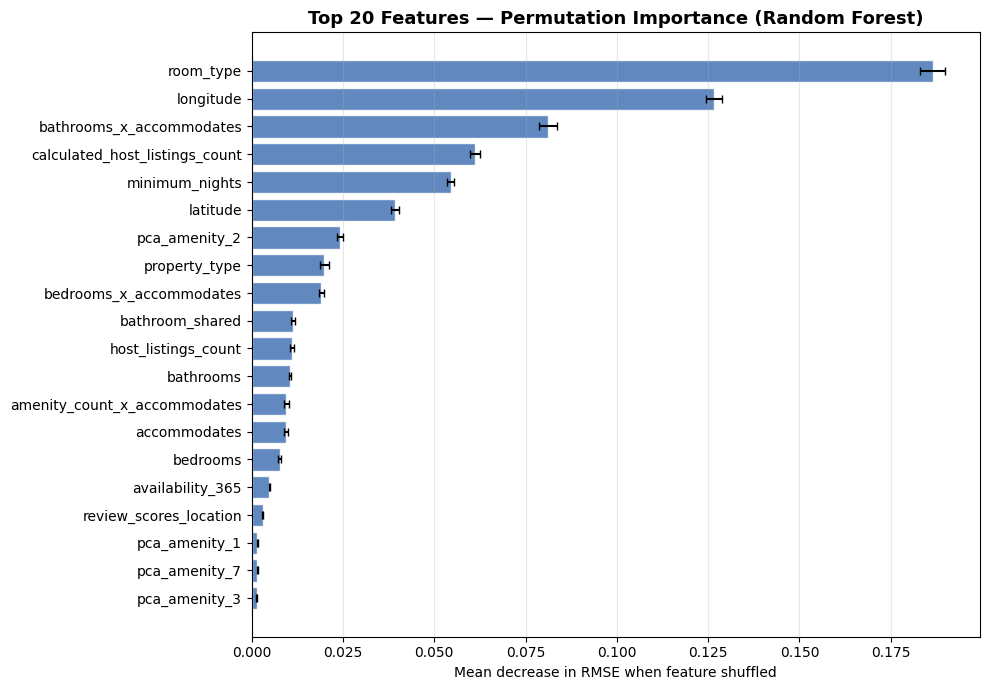

Saved → outputs/eda/rf_permutation_importance.png


In [17]:
top20 = imp_df.head(20).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["feature"], top20["importance"], xerr=top20["std"],
        color="#4575b4", alpha=0.85, edgecolor="white", capsize=3)
ax.set_title("Top 20 Features — Permutation Importance (Random Forest)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean decrease in RMSE when feature shuffled")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/rf_permutation_importance.png")

## 9. Residual Analysis

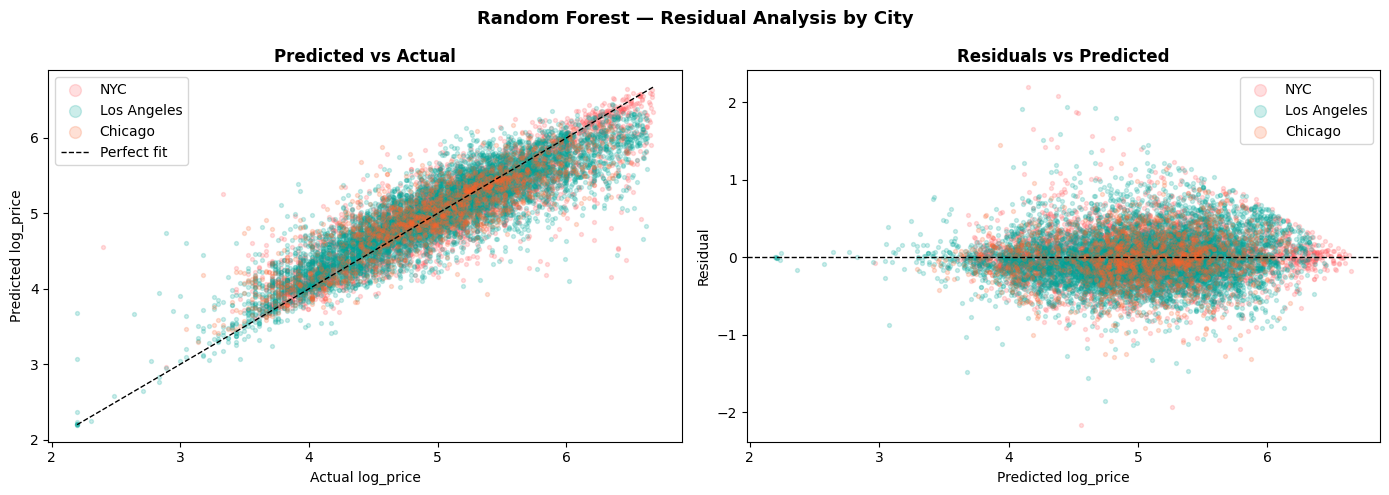

Saved → outputs/eda/rf_residuals.png


In [18]:
residuals = y_test.values - y_pred_test
city_test = df.loc[y_test.index, "city"].values

CITY_COLORS = {"nyc": "#FF5A5F", "la": "#00A699", "chi": "#FC642D"}
CITY_LABELS = {"nyc": "NYC", "la": "Los Angeles", "chi": "Chicago"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
ax = axes[0]
for city, label in CITY_LABELS.items():
    mask = city_test == city
    ax.scatter(y_test.values[mask], y_pred_test[mask],
               alpha=0.2, s=8, color=CITY_COLORS[city], label=label)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect fit")
ax.set_xlabel("Actual log_price"); ax.set_ylabel("Predicted log_price")
ax.set_title("Predicted vs Actual", fontweight="bold")
ax.legend(markerscale=3)

# Residuals vs predicted
ax = axes[1]
for city, label in CITY_LABELS.items():
    mask = city_test == city
    ax.scatter(y_pred_test[mask], residuals[mask],
               alpha=0.2, s=8, color=CITY_COLORS[city], label=label)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted log_price"); ax.set_ylabel("Residual")
ax.set_title("Residuals vs Predicted", fontweight="bold")
ax.legend(markerscale=3)

fig.suptitle("Random Forest — Residual Analysis by City", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/eda/rf_residuals.png")

## 10. Save Model

## 11. Conclusion

| Model | RMSE (log) | MAE (log) | R² |
|---|---|---|---|
| Ridge (baseline) | 0.3599 | 0.2759 | 0.7371 |
| **Random Forest** | **0.3203** | **0.2369** | **0.7917** |

Random Forest outperforms Ridge on all three metrics. The improvement in R² from 0.737 → 0.792 (+5.5 points) confirms that the Airbnb pricing signal is partially non-linear, since neighbourhood effects, size-amenity interactions, and geographic clusters are better captured by tree-based splits than by a linear model.

Key findings from permutation importance:
- **Room type** is the single most important feature (entire home vs private/shared room is a strong price signal).
- **Longitude** ranks second, because it's a proxy for east/west geography within cities (e.g., Manhattan vs outer boroughs in NYC, Venice Beach vs downtown LA).
- **Bathrooms × accommodates** is the top-ranked interaction term, confirming our hypothesis that absolute bathroom supply for a given party size matters beyond individual features.
- PCA amenity components (`pca_amenity_2`, `pca_amenity_1`) rank in the top 20, validating the unsupervised dimensionality reduction approach.

The large gap between train RMSE (0.121) and test RMSE (0.320) shows the model is still somewhat overfit even with tuning, likely because the optimal `max_depth=None` grows fully deep trees. XGBoost with regularization and Bayesian optimisation is explored next.

In [19]:
model_path = MODELS_DIR / "rf_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump({
        "pipeline":    best_rf,
        "params":      grid_search.best_params_,
        "metrics":     results,
        "feature_names": feature_names_out,
        "NUMERIC_COLS": NUMERIC_COLS,
        "CATEGORICAL_COLS": CATEGORICAL_COLS,
    }, f)
print(f"Model saved → {model_path}")
print(f"\nFinal summary:")
print(f"  Best params : {grid_search.best_params_}")
print(f"  Test RMSE   : {results['test_rmse']:.4f}  (Ridge: 0.3599)")
print(f"  Test R²     : {results['test_r2']:.4f}  (Ridge: 0.7371)")

Model saved → ../models/rf_model.pkl

Final summary:
  Best params : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
  Test RMSE   : 0.3203  (Ridge: 0.3599)
  Test R²     : 0.7917  (Ridge: 0.7371)
